# Benchmark ODE Test Problem

This notebook compares **Euler**, **RK2**, and **RK4** on the benchmark initial value problem

\[
$\frac{dy}{dt} = -2y, \qquad y(0)=1$,
\]

with exact solution

\[
$y(t)=e^{-2t}$.
\]

The notebook generates:
- solution comparison data,
- convergence data and observed order,
- a log--log convergence plot,
- a simple timing comparison.

This version is aligned with the report appendix and is formatted to be clean enough for submission.


In [16]:
using Printf
using Plots

# -------------------------
# Benchmark problem
# -------------------------
f(t, y) = -2*y
y_exact(t) = exp(-2*t)

t0 = 0.0
y0 = 1.0
T  = 2.0


2.0

## Numerical methods

In [17]:
function euler(f, t0, y0, T, h)
    @assert h > 0 "Step size h must be positive."
    @assert T >= t0 "Final time T must satisfy T >= t0."

    N = Int(round((T - t0)/h))
    t = collect(range(t0, step=h, length=N+1))
    y = zeros(Float64, N+1)
    y[1] = y0

    for n in 1:N
        y[n+1] = y[n] + h*f(t[n], y[n])
    end

    return t, y
end

function rk2(f, t0, y0, T, h)
    @assert h > 0 "Step size h must be positive."
    @assert T >= t0 "Final time T must satisfy T >= t0."

    N = Int(round((T - t0)/h))
    t = collect(range(t0, step=h, length=N+1))
    y = zeros(Float64, N+1)
    y[1] = y0

    for n in 1:N
        k1 = f(t[n], y[n])
        k2 = f(t[n] + h, y[n] + h*k1)
        y[n+1] = y[n] + (h/2)*(k1 + k2)
    end

    return t, y
end

function rk4(f, t0, y0, T, h)
    @assert h > 0 "Step size h must be positive."
    @assert T >= t0 "Final time T must satisfy T >= t0."

    N = Int(round((T - t0)/h))
    t = collect(range(t0, step=h, length=N+1))
    y = zeros(Float64, N+1)
    y[1] = y0

    for n in 1:N
        k1 = f(t[n], y[n])
        k2 = f(t[n] + h/2, y[n] + (h/2)*k1)
        k3 = f(t[n] + h/2, y[n] + (h/2)*k2)
        k4 = f(t[n] + h,   y[n] + h*k3)

        y[n+1] = y[n] + (h/6)*(k1 + 2k2 + 2k3 + k4)
    end

    return t, y
end


rk4 (generic function with 1 method)

## Accuracy utilities

In [18]:
function max_error(t, y_num, y_exact)
    y_true = [y_exact(ti) for ti in t]
    return maximum(abs.(y_true .- y_num))
end

function empirical_order(Eh, Eh2)
    return log(Eh/Eh2) / log(2)
end


empirical_order (generic function with 1 method)

## Convergence data

In [19]:
hs = [0.4, 0.2, 0.1, 0.05, 0.025]

methods = Dict(
    "Euler" => euler,
    "RK2"   => rk2,
    "RK4"   => rk4
)

errors = Dict{String, Vector{Float64}}()

for (name, method) in methods
    err = Float64[]
    for h in hs
        t, y_num = method(f, t0, y0, T, h)
        push!(err, max_error(t, y_num, y_exact))
    end
    errors[name] = err
end

println("Convergence data")
println("---------------------------------------------------------------")
println("Method    h         max error           observed order")
println("---------------------------------------------------------------")

for name in ["Euler", "RK2", "RK4"]
    err = errors[name]
    for i in eachindex(hs)
        if i == 1
            @printf("%-8s %-8.3f %-18.8e %s\n", name, hs[i], err[i], "-")
        else
            p = empirical_order(err[i-1], err[i])
            @printf("%-8s %-8.3f %-18.8e %.4f\n", name, hs[i], err[i], p)
        end
    end
    println("---------------------------------------------------------------")
end


Convergence data
---------------------------------------------------------------
Method    h         max error           observed order
---------------------------------------------------------------
Euler    0.400    2.49328964e-01     -
Euler    0.200    8.93289641e-02     1.4809
Euler    0.100    4.01994412e-02     1.1520
Euler    0.050    1.92010011e-02     1.0660
Euler    0.025    9.39351876e-03     1.0314
---------------------------------------------------------------
RK2      0.400    7.06710359e-02     -
RK2      0.200    1.32377881e-02     2.4165
RK2      0.100    2.86040203e-03     2.2104
RK2      0.050    6.61543662e-04     2.1123
RK2      0.025    1.59180500e-04     2.0552
---------------------------------------------------------------
RK4      0.400    2.40436922e-03     -
RK4      0.200    1.07789752e-04     4.4794
RK4      0.100    5.79695386e-06     4.2168
RK4      0.050    3.33241056e-07     4.1207
RK4      0.025    1.99760973e-08     4.0602
---------------------------

## Plot 1: Numerical solution comparison

In [20]:
h_plot = 0.2

t_e, y_e     = euler(f, t0, y0, T, h_plot)
t_rk2, y_rk2 = rk2(f, t0, y0, T, h_plot)
t_rk4, y_rk4 = rk4(f, t0, y0, T, h_plot)

t_exact = 0:0.01:T
y_true = [y_exact(ti) for ti in t_exact]

plot(t_exact, y_true, label="Exact", linewidth=3)
plot!(t_e, y_e, marker=:circle, label="Euler")
plot!(t_rk2, y_rk2, marker=:square, label="RK2")
plot!(t_rk4, y_rk4, marker=:diamond, label="RK4")
xlabel!("t")
ylabel!("y(t)")
title!("Comparison of Euler, RK2, and RK4 for y' = -2y")

savefig("comparison_plot.png")
println("Saved comparison plot to comparison_plot.png")


Saved comparison plot to comparison_plot.png


## Plot 2: Convergence plot

In [21]:
plot(
    hs, errors["Euler"],
    xscale=:log10, yscale=:log10,
    marker=:circle, linewidth=2, label="Euler"
)
plot!(hs, errors["RK2"], marker=:square, linewidth=2, label="RK2")
plot!(hs, errors["RK4"], marker=:diamond, linewidth=2, label="RK4")
xlabel!("Step size h")
ylabel!("Maximum global error")
title!("Convergence of Euler, RK2, and RK4")

savefig("convergence_plot.png")
println("Saved convergence plot to convergence_plot.png")


Saved convergence plot to convergence_plot.png


## Plot 3: Timing comparison

In [22]:
timing_h = 0.001
repeats = 200

avg_times = Dict{String, Float64}()

for (name, method) in methods
    vals = Float64[]
    for _ in 1:repeats
        elapsed = @elapsed method(f, t0, y0, T, timing_h)
        push!(vals, elapsed)
    end
    avg_times[name] = sum(vals) / length(vals)
end

println("Average runtimes:")
for name in ["Euler", "RK2", "RK4"]
    @printf("%s: %.6e s\n", name, avg_times[name])
end

bar(
    ["Euler", "RK2", "RK4"],
    [avg_times["Euler"], avg_times["RK2"], avg_times["RK4"]],
    label="",
    xlabel="Method",
    ylabel="Average runtime (s)",
    title="Average Computational Time of Numerical Methods"
)

savefig("timing_plot.png")
println("Saved timing plot to timing_plot.png")


Average runtimes:
Euler: 2.056334e-05 s
RK2: 9.448602e-05 s
RK4: 2.066436e-03 s
Saved timing plot to timing_plot.png


# SIR Model - Numerical Integration

This notebook implements the SIR (Susceptible-Infected-Recovered) epidemiological model using three numerical integration methods:
- Euler method
- RK2 (Runge-Kutta 2nd order)
- RK4 (Runge-Kutta 4th order)

In [23]:
using Plots

# SIR model right-hand side
function sir_rhs(t, y, beta, gamma)
    S, I, R = y
    dS = -beta * S * I
    dI =  beta * S * I - gamma * I
    dR =  gamma * I
    return [dS, dI, dR]
end

sir_rhs (generic function with 1 method)

## Numerical Integration Methods

In [24]:
# Euler method
function euler_system(f, t0, y0, T, h)
    N = Int(round((T - t0)/h))
    t = zeros(N + 1)
    Y = zeros(length(y0), N + 1)

    t[1] = t0
    Y[:, 1] = y0

    for n in 1:N
        t[n+1] = t[n] + h
        Y[:, n+1] = Y[:, n] + h * f(t[n], Y[:, n])
    end

    return t, Y
end

euler_system (generic function with 1 method)

In [25]:
# RK2 method
function rk2_system(f, t0, y0, T, h)
    N = Int(round((T - t0)/h))
    t = zeros(N + 1)
    Y = zeros(length(y0), N + 1)

    t[1] = t0
    Y[:, 1] = y0

    for n in 1:N
        t[n+1] = t[n] + h

        k1 = f(t[n], Y[:, n])
        y_star = Y[:, n] + h * k1
        k2 = f(t[n] + h, y_star)

        Y[:, n+1] = Y[:, n] + (h/2.0) * (k1 + k2)
    end

    return t, Y
end

rk2_system (generic function with 1 method)

In [26]:
# RK4 method
function rk4_system(f, t0, y0, T, h)
    N = Int(round((T - t0)/h))
    t = zeros(N + 1)
    Y = zeros(length(y0), N + 1)

    t[1] = t0
    Y[:, 1] = y0

    for n in 1:N
        t[n+1] = t[n] + h

        k1 = f(t[n], Y[:, n])
        k2 = f(t[n] + h/2.0, Y[:, n] + (h/2.0)*k1)
        k3 = f(t[n] + h/2.0, Y[:, n] + (h/2.0)*k2)
        k4 = f(t[n] + h,     Y[:, n] + h*k3)

        Y[:, n+1] = Y[:, n] + (h/6.0) * (k1 + 2k2 + 2k3 + k4)
    end

    return t, Y
end

rk4_system (generic function with 1 method)

## Solve the SIR Model

In [27]:
# Parameters
beta = 0.35
gamma = 0.10
t0 = 0.0
T = 160.0
h = 0.5

# Initial conditions
S0 = 0.95
I0 = 0.05
R0 = 0.0
y0 = [S0, I0, R0]

# Create wrapped function
f_sir(t, y) = sir_rhs(t, y, beta, gamma)

# Solve using all three methods
t_e, Y_e = euler_system(f_sir, t0, y0, T, h)
t_rk2, Y_rk2 = rk2_system(f_sir, t0, y0, T, h)
t_rk4, Y_rk4 = rk4_system(f_sir, t0, y0, T, h)

([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5  …  155.5, 156.0, 156.5, 157.0, 157.5, 158.0, 158.5, 159.0, 159.5, 160.0], [0.95 0.9412280753726261 … 0.032098668697786596 0.03209865764669247; 0.05 0.05612149572145713 … 2.011324952241562e-6 1.9240088512294237e-6; 0.0 0.0026504289059167165 … 0.9678993199772612 0.9678994183444564])

## Plotting Results

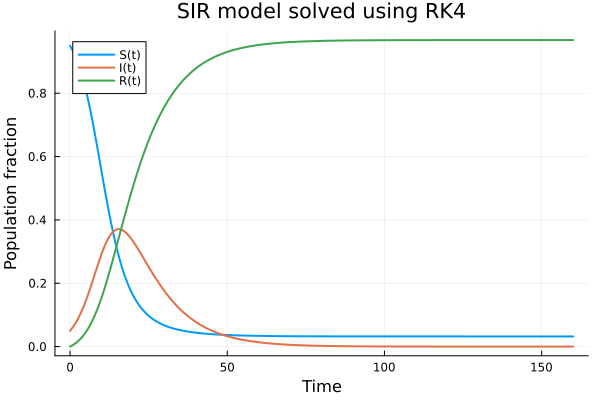

In [28]:
# Plot RK4 SIR solution
plot(t_rk4, Y_rk4[1, :], label="S(t)", linewidth=2)
plot!(t_rk4, Y_rk4[2, :], label="I(t)", linewidth=2)
plot!(t_rk4, Y_rk4[3, :], label="R(t)", linewidth=2)
xlabel!("Time")
ylabel!("Population fraction")
title!("SIR model solved using RK4")
savefig("sir_rk4.png")
plot!()

## Population Conservation Check

In [29]:
# Verify that S + I + R = 1 (conservation of population)
total_population = Y_rk4[1, :] .+ Y_rk4[2, :] .+ Y_rk4[3, :]
max_conservation_error = maximum(abs.(total_population .- 1.0))
println("Maximum conservation error: $max_conservation_error")

Maximum conservation error: 2.220446049250313e-16


In [30]:
# =========================================================
# Extended SIR simulations for appendix
# =========================================================

using Plots
using Printf

# SIR right-hand side
function sir_rhs(S, I, R, beta, gamma)
    dS = -beta * S * I
    dI = beta * S * I - gamma * I
    dR = gamma * I
    return dS, dI, dR
end

# RK4 solver for SIR system
function sir_rk4(S0, I0, R0, beta, gamma, tspan, h)
    t0, tf = tspan
    t = collect(t0:h:tf)
    n = length(t)

    S = zeros(n)
    I = zeros(n)
    R = zeros(n)

    S[1] = S0
    I[1] = I0
    R[1] = R0

    for k in 1:n-1
        dS1, dI1, dR1 = sir_rhs(S[k], I[k], R[k], beta, gamma)

        dS2, dI2, dR2 = sir_rhs(
            S[k] + 0.5h*dS1,
            I[k] + 0.5h*dI1,
            R[k] + 0.5h*dR1,
            beta, gamma
        )

        dS3, dI3, dR3 = sir_rhs(
            S[k] + 0.5h*dS2,
            I[k] + 0.5h*dI2,
            R[k] + 0.5h*dR2,
            beta, gamma
        )

        dS4, dI4, dR4 = sir_rhs(
            S[k] + h*dS3,
            I[k] + h*dI3,
            R[k] + h*dR3,
            beta, gamma
        )

        S[k+1] = S[k] + (h/6)*(dS1 + 2dS2 + 2dS3 + dS4)
        I[k+1] = I[k] + (h/6)*(dI1 + 2dI2 + 2dI3 + dI4)
        R[k+1] = R[k] + (h/6)*(dR1 + 2dR2 + 2dR3 + dR4)
    end

    return t, S, I, R
end

# Helper function for summary statistics
function sir_summary(t, I)
    Imax, idx = findmax(I)
    tpeak = t[idx]
    return Imax, tpeak
end

# Common settings
gamma = 0.10
beta_base = 0.35
tspan_sir = (0.0, 160.0)
h_sir = 0.5

# ---------------------------------------------------------
# 1) Effect of initial infection level
# ---------------------------------------------------------
initial_cases = [
    (0.99, 0.01, 0.00, "I₀ = 0.01"),
    (0.95, 0.05, 0.00, "I₀ = 0.05"),
    (0.90, 0.10, 0.00, "I₀ = 0.10")
]

p1 = plot(title = "Effect of Initial Infection Level on I(t)",
          xlabel = "Time",
          ylabel = "Infected Fraction",
          linewidth = 2)

println("\nExtended SIR results: varying initial infection level")
println("Case        Imax        t_peak")

for (S0, I0, R0, label) in initial_cases
    t, S, I, R = sir_rk4(S0, I0, R0, beta_base, gamma, tspan_sir, h_sir)
    plot!(p1, t, I, label = label)

    Imax, tpeak = sir_summary(t, I)
    @printf("%-10s  %.4f      %.2f\n", label, Imax, tpeak)
end

savefig(p1, "sir_initial_conditions.png")

# ---------------------------------------------------------
# 2) Effect of beta / R0
# ---------------------------------------------------------
parameter_cases = [
    (0.05, gamma, "R₀ = 0.5"),
    (0.10, gamma, "R₀ = 1.0"),
    (0.35, gamma, "R₀ = 3.5")
]

S0_par = 0.95
I0_par = 0.05
R0_par = 0.00

p2 = plot(title = "Effect of Basic Reproduction Number on I(t)",
          xlabel = "Time",
          ylabel = "Infected Fraction",
          linewidth = 2)

println("\nExtended SIR results: varying reproduction number")
println("Case        Imax        t_peak")

for (beta, gamma_val, label) in parameter_cases
    t, S, I, R = sir_rk4(S0_par, I0_par, R0_par, beta, gamma_val, tspan_sir, h_sir)
    plot!(p2, t, I, label = label)

    Imax, tpeak = sir_summary(t, I)
    @printf("%-10s  %.4f      %.2f\n", label, Imax, tpeak)
end

savefig(p2, "sir_R0_comparison.png")

# ---------------------------------------------------------
# 3) Optional conservation check
# ---------------------------------------------------------
t, S_chk, I_chk, R_chk = sir_rk4(0.95, 0.05, 0.0, beta_base, gamma, tspan_sir, h_sir)
mass_error = maximum(abs.(S_chk .+ I_chk .+ R_chk .- 1.0))
@printf("\nMaximum conservation error: %.6e\n", mass_error)


Extended SIR results: varying initial infection level
Case        Imax        t_peak
I₀ = 0.01   0.3592      22.50
I₀ = 0.05   0.3710      15.50
I₀ = 0.10   0.3863      12.00

Extended SIR results: varying reproduction number
Case        Imax        t_peak
R₀ = 0.5    0.0500      0.00
R₀ = 1.0    0.0500      0.00
R₀ = 3.5    0.3710      15.50

Maximum conservation error: 2.220446e-16
